# Discovery of metastable structure in simulated Duffing data

In [1]:
import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..', '..'))
sys.path.append(root_dir)

data_dir = f'{root_dir}/data/regimes/duffing'

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scipy.spatial.distance import cdist

from itertools import groupby
from operator import itemgetter

import kind
import util_nn
import util_data

### Read windows data

In [2]:
def normalize_standard(timeseries, mean, std):
    return (timeseries - mean) / std

def denormalize_standard(timeseries, mean, std):
    return timeseries * std + mean

class dataset(torch.utils.data.Dataset):
    def __init__(self, back, fore):
        self.back = back
        self.fore = fore

    def __len__(self):
        return len(self.back)

    def __getitem__(self, idx):
        return self.back[idx], self.fore[idx]

# --! read windows data from a file
traj_nsample = 1280
window_nsample = 96
data = util_data.read_datafile(f'{data_dir}/windows', window_nsample)
print(f'inf > read data shape: {data.shape}')

# --! get normalization constants per channel
std_min = torch.tensor(1e-3, dtype=torch.float32)
data_mean = [d.mean() for d in torch.split(data, 1, dim=-1)]
data_std = [torch.maximum(d.std(), std_min) for d in torch.split(data, 1, dim=-1)]

# --! normalize data
data = torch.cat([
    normalize_standard(
        d, mean, std) for d, mean, std in zip(torch.split(data, 1, dim=-1), data_mean, data_std)], dim=-1)

# --! split windows into lookback and forecast parts
fore_nsample = 32
back_nsample = 2 * fore_nsample
back, fore = torch.split(data, [back_nsample, fore_nsample], dim=-2)

# --! create dataset and dataloader
dataset = dataset(back, fore)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

#dataset = regime_dataset(data, back_nsample, fore_nsample)
#dataloader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=False)

inf > read data shape: torch.Size([9480, 96, 2])


### Instantiate past and future regime encoders

In [3]:
# --! set seed to get reproducible behavior
util_nn.set_seed(2026)

In [4]:
# --! instantiate encoders
window_ndim = data.shape[-1]
latent_ndim = 3
back_enc = kind.regime_encoder(back_nsample, window_ndim, latent_ndim)
fore_enc = kind.regime_encoder(fore_nsample, window_ndim, latent_ndim)

In [5]:

def variance_loss(z):

    std = torch.sqrt(z.var(dim=0) + 1e-4)
    return torch.mean(torch.relu(1.0 - std))

def train_enc(back_enc, fore_enc, dataloader, nepoch=100):
    optimizer = torch.optim.Adam(list(back_enc.parameters()) + list(fore_enc.parameters()), lr=1e-3)

    for epoch in range(nepoch):
        total_loss = 0.0

        for back, fore in dataloader:
            z = back_enc(torch.flatten(back, start_dim=1))
            h = fore_enc(torch.flatten(fore, start_dim=1))
            loss = F.mse_loss(z, h) + 0.01 * variance_loss(z) + 0.01 * variance_loss(h)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"epoch {epoch}, loss: {total_loss / len(dataloader):.6f}")

In [6]:
train_enc(back_enc, fore_enc, dataloader, nepoch=100)


epoch 0, loss: 0.017437
epoch 20, loss: 0.000202
epoch 40, loss: 0.000315
epoch 60, loss: 0.000014
epoch 80, loss: 0.000003


### Create latent space

In [7]:

data = util_data.read_datafile(f'{data_dir}/windows', window_nsample)

# --! normalize data
data = torch.cat([
    normalize_standard(
        d, mean, std) for d, mean, std in zip(torch.split(data, 1, dim=-1), data_mean, data_std)], dim=-1)

back, fore = torch.split(data, [back_nsample, fore_nsample], dim=-2)

# --! encode lookback windows
z = back_enc(torch.flatten(back, start_dim=1))
z_np = z.detach().cpu().numpy()

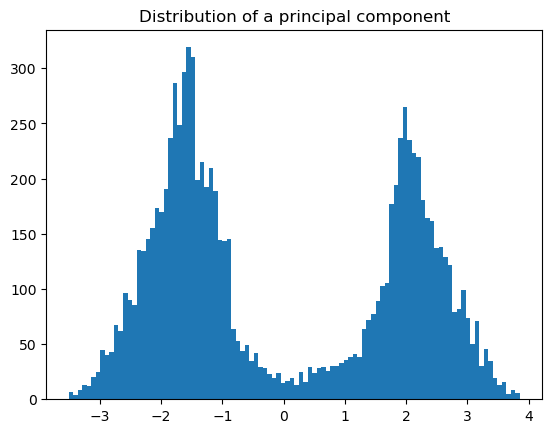

In [8]:
# --! latent space diagnostic --!

# --! extract the principal component from our latent space
s = PCA(n_components=1).fit_transform(z_np).squeeze()

# --! display the principal component on a histogram
plt.figure()
plt.title('Distribution of a principal component')
plt.hist(s, bins=100)
plt.show()


In [9]:
# --! cluster encoded latent space --!

def compute_cluster_residences(cluster_labels):

    # --! compute residence time in each cluster as a list of tuples (cluster index, residence)
    cluster_residences = [(key, sum(1 for _ in group)) for key, group in groupby(cluster_labels)]

    # --! sort the residences by cluster indeces
    cluster_residences = sorted(cluster_residences, key=itemgetter(0))

    # --! group unique cluster indeces together and average their corresponding residences
    cluster_residences_avg = []
    for i, group in groupby(cluster_residences, key=itemgetter(0)):
        residences = [r for _, r in group]
        cluster_residences_avg.append((i, int(sum(residences) / len(residences))))

    # --! sort residence list in descending order, such that
    # --! short transition corridors move to the end of this list
    cluster_residences_avg = sorted(cluster_residences_avg, key=itemgetter(1))[::-1]

    return cluster_residences_avg

# --! we expect three clusters to come up in data: well (1,0), well (-1,0) and transition
ncluster = 3

# --! cluster using KMeans while setting its tolerance to tune allowed distances
kmeans_tolerance = 8e-6
kmeans = KMeans(n_clusters=ncluster, tol=kmeans_tolerance).fit(z_np)

# --! compute average residences per cluster, sorted in descending order, that is
# --! the excursion corridor with least residence appears last
cluster_residences = compute_cluster_residences(kmeans.labels_)
print(cluster_residences)


[(np.int32(1), 223), (np.int32(2), 221), (np.int32(0), 20)]


In [10]:
# --! compute risk signal rho that shows proximity to nominal regions --!

# --! compute rho as a euclidean distance between latent space points and cluster centers
rho = cdist(z_np, kmeans.cluster_centers_, metric='euclidean')

# --! rho is computed as a continuous distance signal for every cluster, thus to
# --! compute proximity to nominal regions we take the minimum of the
# --! two nominal regions established in this Duffing example
rho_nom = np.minimum(rho[:, cluster_residences[0][0]], rho[:, cluster_residences[1][0]])

# --! rho star serves as a threshold between the nominal and excursion regions
rho_star = np.percentile(rho_nom, 90)


(450,)
(450,)


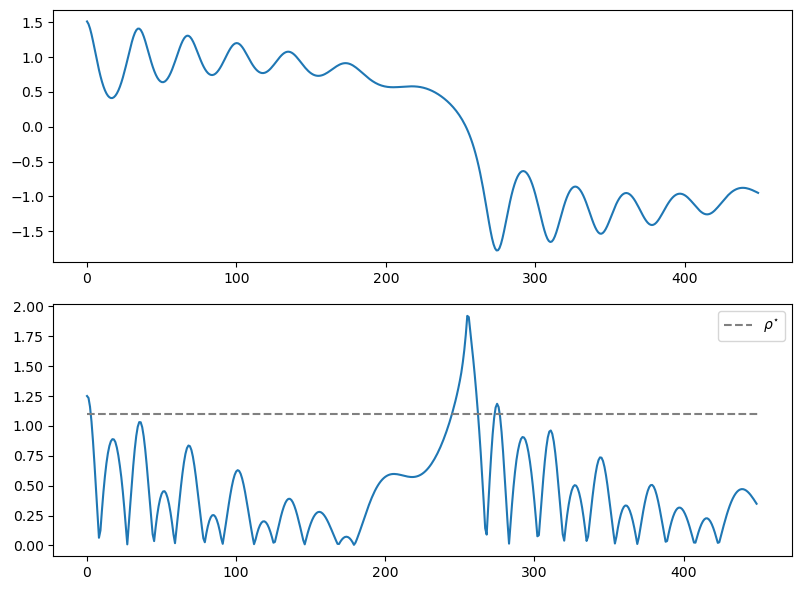

In [11]:

test_data = data.numpy()[420:420+450, 64, 0]
test_rho_nom = rho_nom[420:420+450]
print(test_data.shape)
print(test_rho_nom.shape)

plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.plot(test_data)

plt.subplot(2,1,2)
plt.plot(test_rho_nom)
plt.plot([0, 450], [rho_star, rho_star], color='gray', linestyle='dashed', label=r'$\rho^{\star}$')
plt.legend()

plt.tight_layout()
plt.show()